In [1]:
# Preprocesamiento
import pandas as pd
import numpy as np
import datetime as dt

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
)
from sklearn.preprocessing import (
    OneHotEncoder, LabelEncoder, OrdinalEncoder, MinMaxScaler, StandardScaler
)
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE

# Modelos
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV, SGDClassifier
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier, plot_importance
from sklearn.cluster import KMeans

# Métricas y evaluación
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score,
    balanced_accuracy_score, accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, classification_report, make_scorer
)
from statistics import stdev

#optimización de hiperparámetros
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Visualización
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')

import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

# Otros
import joblib
import shap
from collections import Counter
import glob  # leer archivos con el mismo nombre de una ruta especifica
import os #direcciones

# Configuración para pandas
pd.set_option('display.max_colwidth', None)
pd.set_option('display.width', None)
pd.set_option('display.max_columns', None)  # Mostrar todas las columnas
pd.set_option('display.max_rows', None)     # Mostrar todas las filas
pd.options.display.float_format = '{:.4f}'.format

# Ajustar tamaño de la ventana en Jupyter Notebook
from IPython.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))

# Suprimir advertencias
import warnings
warnings.filterwarnings("ignore")


c:\Users\eusou\anaconda3\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


os.chdir(r'C:\William 2022\Empleo\TUYA Cobranzas cientifico de datos\Tuya prueba William Amaya 1072643861')
filenames = glob.glob('ProductoNuevo.xlsx')
data = pd.DataFrame([])
for file in filenames:
    print (file)
    temp = pd.read_excel(file)  #encoding='ansi'
  #  temp['PERIODO'] = int(file[-9:-5]+file[-11:-9])
    #temp['PERIODO'] = int(202301)
    data = pd.concat([data,temp])
    

In [2]:
data = pd.read_csv("prueba_analist_de_datos_crecere.csv")

In [3]:
data.head()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,48195063.4487,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,61921106.5466,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,35050550.3778,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,85989430.6533,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,11445571.3326,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


In [4]:
data.shape

(1000, 17)

In [5]:
data.isnull().sum()/len(data)*100

antiguedad_deuda         0.0000
deuda_total              0.0000
mujer                    0.0000
edad                     0.0000
region_bogota            0.0000
propuesta_cuotas         0.0000
propuesta_descuento      0.0000
estrategia_agresiva      0.0000
origen_deudor            0.0000
estado_civil             0.0000
tiene_propiedades        0.0000
producto_origen_deuda    0.0000
beneficiario_subsidios   0.0000
helado_favorito          0.0000
mes                      0.0000
ingreso                  0.0000
con_acuerdo              0.0000
dtype: float64

In [6]:
data.duplicated().sum()

np.int64(0)

In [7]:
data.shape

(1000, 17)

In [8]:
data.head()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,48195063.4487,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,61921106.5466,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,35050550.3778,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,85989430.6533,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,11445571.3326,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


In [9]:
data['con_acuerdo'].value_counts()

con_acuerdo
0    912
1     88
Name: count, dtype: int64

In [10]:
data.columns

Index(['antiguedad_deuda', 'deuda_total', 'mujer', 'edad', 'region_bogota',
       'propuesta_cuotas', 'propuesta_descuento', 'estrategia_agresiva',
       'origen_deudor', 'estado_civil', 'tiene_propiedades',
       'producto_origen_deuda', 'beneficiario_subsidios', 'helado_favorito',
       'mes', 'ingreso', 'con_acuerdo'],
      dtype='object')

In [11]:
data.head()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,48195063.4487,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,61921106.5466,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,35050550.3778,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,85989430.6533,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,11445571.3326,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


In [12]:

import unicodedata

# Función para limpiar los nombres de columnas
def limpiar_columna(col):
    # Quitar tildes y acentos
    col = ''.join(
        c for c in unicodedata.normalize('NFD', col)
        if unicodedata.category(c) != 'Mn'
    )
    # Convertir a minúsculas y reemplazar espacios por guiones bajos
    col = col.lower().replace(' ', '_')
    return col

# Aplicar la función a todas las columnas
data.columns = [limpiar_columna(c) for c in data.columns]


In [13]:
data.head()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,48195063.4487,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,61921106.5466,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,35050550.3778,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,85989430.6533,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,11445571.3326,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


In [14]:
data.shape

(1000, 17)

In [15]:
data.duplicated().sum()

np.int64(0)

In [16]:
data.to_excel("prueba_analist_de_datos_crecere_limpio.xlsx")

In [17]:
data.isnull().sum()/len(data)*100

antiguedad_deuda         0.0000
deuda_total              0.0000
mujer                    0.0000
edad                     0.0000
region_bogota            0.0000
propuesta_cuotas         0.0000
propuesta_descuento      0.0000
estrategia_agresiva      0.0000
origen_deudor            0.0000
estado_civil             0.0000
tiene_propiedades        0.0000
producto_origen_deuda    0.0000
beneficiario_subsidios   0.0000
helado_favorito          0.0000
mes                      0.0000
ingreso                  0.0000
con_acuerdo              0.0000
dtype: float64

In [18]:
# Contar valores nulos y no nulos
a = data.isnull().sum()  # Número de valores nulos por columna
b = data.notnull().sum()  # Número de valores no nulos por columna
c = data.shape[0]  # Número total de filas (constante para todas las columnas)

# Calcular porcentajes
d = round(a / c * 100, 4)  # % de valores nulos por columna
e = round(b / c * 100, 4)  # % de valores no nulos por columna

# Combinar resultados en un DataFrame
result = pd.concat([a, b, pd.Series(c, index=data.columns), d, e], axis=1)
result.columns = [
    "# of Unknown df",  # Nulos
    "# of Known df",    # No nulos
    "# of Total df",    # Total
    "% of Unknown df",  # % de nulos
    "% of Known df"     # % de no nulos
]
result

,# of Unknown df,# of Known df,# of Total df,% of Unknown df,% of Known df
antiguedad_deuda,0,1000,1000,0.0000,100.0000
deuda_total,0,1000,1000,0.0000,100.0000
mujer,0,1000,1000,0.0000,100.0000
edad,0,1000,1000,0.0000,100.0000
region_bogota,0,1000,1000,0.0000,100.0000
propuesta_cuotas,0,1000,1000,0.0000,100.0000
propuesta_descuento,0,1000,1000,0.0000,100.0000
estrategia_agresiva,0,1000,1000,0.0000,100.0000
origen_deudor,0,1000,1000,0.0000,100.0000
estado_civil,0,1000,1000,0.0000,100.0000


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   antiguedad_deuda        1000 non-null   int64  
 1   deuda_total             1000 non-null   float64
 2   mujer                   1000 non-null   int64  
 3   edad                    1000 non-null   float64
 4   region_bogota           1000 non-null   int64  
 5   propuesta_cuotas        1000 non-null   int64  
 6   propuesta_descuento     1000 non-null   float64
 7   estrategia_agresiva     1000 non-null   int64  
 8   origen_deudor           1000 non-null   object 
 9   estado_civil            1000 non-null   object 
 10  tiene_propiedades       1000 non-null   int64  
 11  producto_origen_deuda   1000 non-null   object 
 12  beneficiario_subsidios  1000 non-null   int64  
 13  helado_favorito         1000 non-null   object 
 14  mes                     1000 non-null   i

In [20]:
data['region_bogota'].value_counts(dropna=False)

region_bogota
0    695
1    305
Name: count, dtype: int64

In [21]:
data['estrategia_agresiva'].value_counts(dropna=False)

estrategia_agresiva
0    505
1    495
Name: count, dtype: int64

In [22]:
data['con_acuerdo'].value_counts(dropna=False)

con_acuerdo
0    912
1     88
Name: count, dtype: int64

In [23]:
data.describe()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,tiene_propiedades,beneficiario_subsidios,mes,ingreso,con_acuerdo
count,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000,1000.0000
mean,764.6540,44585388.6968,0.5080,35.0166,0.3050,6.4970,0.2934,0.4950,0.1640,0.0840,6.4770,3685860.7710,0.0880
std,337.4223,26403428.9752,0.5002,8.7203,0.4606,3.4863,0.1732,0.5002,0.3705,0.2775,3.5592,1183487.5723,0.2834
min,182.0000,953929.2073,0.0000,18.0000,0.0000,1.0000,0.0001,0.0000,0.0000,0.0000,1.0000,690423.6141,0.0000
25%,482.0000,21238318.8608,0.0000,29.3142,0.0000,3.0000,0.1472,0.0000,0.0000,0.0000,3.0000,2807265.0221,0.0000
50%,745.5000,43756150.6499,1.0000,34.7599,0.0000,7.0000,0.2931,0.0000,0.0000,0.0000,7.0000,3667244.4539,0.0000
75%,1054.2500,68354386.2658,1.0000,41.3197,1.0000,9.0000,0.4392,1.0000,0.0000,0.0000,10.0000,4495535.9547,0.0000
max,1350.0000,89899983.0466,1.0000,61.8088,1.0000,12.0000,0.5984,1.0000,1.0000,1.0000,12.0000,6996183.2634,1.0000


In [24]:
data.columns

Index(['antiguedad_deuda', 'deuda_total', 'mujer', 'edad', 'region_bogota',
       'propuesta_cuotas', 'propuesta_descuento', 'estrategia_agresiva',
       'origen_deudor', 'estado_civil', 'tiene_propiedades',
       'producto_origen_deuda', 'beneficiario_subsidios', 'helado_favorito',
       'mes', 'ingreso', 'con_acuerdo'],
      dtype='object')

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   antiguedad_deuda        1000 non-null   int64  
 1   deuda_total             1000 non-null   float64
 2   mujer                   1000 non-null   int64  
 3   edad                    1000 non-null   float64
 4   region_bogota           1000 non-null   int64  
 5   propuesta_cuotas        1000 non-null   int64  
 6   propuesta_descuento     1000 non-null   float64
 7   estrategia_agresiva     1000 non-null   int64  
 8   origen_deudor           1000 non-null   object 
 9   estado_civil            1000 non-null   object 
 10  tiene_propiedades       1000 non-null   int64  
 11  producto_origen_deuda   1000 non-null   object 
 12  beneficiario_subsidios  1000 non-null   int64  
 13  helado_favorito         1000 non-null   object 
 14  mes                     1000 non-null   i

# Revisión de valores atípicos aplicando el método del rango intercuartílico (IQR)


df = data.copy()
df = data.drop(['OCUPACION', 'TIPCONTRATO','Estado_Civil', 'Genero','Nivel_Academico','Tipo_Vivienda', 'ID','FFECHA'], axis=1)
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

outliers = ((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))
print(outliers.any())   # True si hay alguno


plt.figure(figsize=(30, 6))
titulo = 'Revisión de valores atípicos aplicando el método del rango intercuartílico (IQR)'
plt.title(titulo, fontsize=20)
plt.xlabel('Variables', fontsize=15)
plt.ylabel('Valores', fontsize=15)

# Plot the boxplot
df.boxplot()
plt.xticks(rotation=0)
plt.show()

data_f = data[data['TiempoActividad'] == 866880]
data_f.head()

data = data[data['TiempoActividad'] != 866880]

plt.figure(figsize=(30, 6))

# Plot the boxplot
data.boxplot()
plt.xticks(rotation=0)
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Calcular el total de registros
total_mora30 = data['con_acuerdo'].count()

# Crear la figura
plt.figure(figsize=(10, 6))

# Gráfico único de Mora30
grafica_mora30 = sns.countplot(x='con_acuerdo', data=data, palette='Set2')
grafica_mora30.set_title("Distribución de clientes con Acuerdo\n0: Sin acuerdo | 1: Con acuerdo", fontsize=20)
grafica_mora30.set_xlabel("Acuerdo", fontsize=16)
grafica_mora30.set_ylabel("Cantidad de clientes", fontsize=16)

# Añadir porcentajes sobre cada barra
for p in grafica_mora30.patches:
    height = p.get_height()
    grafica_mora30.text(
        p.get_x() + p.get_width() / 2.,
        height + (total_mora30 * 0.01),
        '{:1.2f}%'.format(height / total_mora30 * 100),
        ha="center",
        fontsize=13
    )

plt.tight_layout()
plt.show()


In [26]:
data.head()

,antiguedad_deuda,deuda_total,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,48195063.4487,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,61921106.5466,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,35050550.3778,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,85989430.6533,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,11445571.3326,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


data['PERIODO'] = data['fecha_de_aplicacion'].copy()
data['PERIODO'] = data['PERIODO'].astype(str).str.replace('-','')
data['fecha_aplicacion'] = [str(elem)[0:8] for elem in data['PERIODO']]
data['fecha_aplicacion'] = pd.to_datetime(data['fecha_aplicacion'],format ='%Y%m%d')
data['anio_mes_aplicacion'] = [str(elem)[0:7] for elem in data['fecha_aplicacion']]
data['mes_aplicacion'] = data['fecha_de_aplicacion'].dt.month

In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   antiguedad_deuda        1000 non-null   int64  
 1   deuda_total             1000 non-null   float64
 2   mujer                   1000 non-null   int64  
 3   edad                    1000 non-null   float64
 4   region_bogota           1000 non-null   int64  
 5   propuesta_cuotas        1000 non-null   int64  
 6   propuesta_descuento     1000 non-null   float64
 7   estrategia_agresiva     1000 non-null   int64  
 8   origen_deudor           1000 non-null   object 
 9   estado_civil            1000 non-null   object 
 10  tiene_propiedades       1000 non-null   int64  
 11  producto_origen_deuda   1000 non-null   object 
 12  beneficiario_subsidios  1000 non-null   int64  
 13  helado_favorito         1000 non-null   object 
 14  mes                     1000 non-null   i

In [28]:
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_risk_panel_two_bars(
    data: pd.DataFrame,
    variables: list,
    target_col: str = "con_acuerdo",
    top_k: int = 6,
    suptitle: str = "Porcentaje de acuerdo vs no acuerdo por categoría",
    sort_by: str = "count"  # "count" o "diff"
):
    df = data.copy()

    # --- Validar target ---
    if target_col not in df.columns:
        raise ValueError(f"No encuentro '{target_col}'. Columnas: {list(df.columns)}")

    # --- Normalizar target a 0/1 ---
    if df[target_col].dtype == object:
        s = df[target_col].astype(str).str.strip().str.upper()
        mapping = {
            "1": 1, "0": 0,
            "SI": 1, "SÍ": 1, "NO": 0,
            "TRUE": 1, "FALSE": 0,
            "VERDADERO": 1, "FALSO": 0
        }
        df[target_col] = s.map(mapping)

    if df[target_col].dtype == bool:
        df[target_col] = df[target_col].astype(int)

    df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
    df = df[df[target_col].isin([0, 1])].copy()
    df[target_col] = df[target_col].astype(int)

    df["_estado"] = df[target_col].map({0: "Sin acuerdo", 1: "Con acuerdo"})

    # --- Validar variables ---
    variables_ok = [v for v in variables if v in df.columns]
    if not variables_ok:
        raise ValueError("No hay variables válidas para graficar.")

    n_vars = len(variables_ok)
    ncols = 2 if n_vars >= 2 else n_vars
    nrows = math.ceil(n_vars / ncols)

    sns.set_style("whitegrid")
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 4*nrows), sharey=True)
    axes = axes.flatten()

    palette = {"Sin acuerdo": "#d62728", "Con acuerdo": "#2ca02c"}
    hue_order = ["Sin acuerdo", "Con acuerdo"]

    for i, var in enumerate(variables_ok):
        ax = axes[i]
        sub = df[[var, "_estado"]].dropna()

        is_binary = set(sub[var].unique()).issubset({0, 1})

        counts = (
            sub.groupby([var, "_estado"])
               .size()
               .reset_index(name="count")
        )

        counts["total_cat"] = counts.groupby(var)["count"].transform("sum")
        counts["pct"] = counts["count"] / counts["total_cat"] * 100

        # Selección de categorías
        if is_binary:
            top_cats = [0, 1]
        else:
            totals = counts.groupby(var)["count"].sum().sort_values(ascending=False)
            top_cats = totals.head(top_k).index.tolist()

        counts = counts[counts[var].isin(top_cats)].copy()

        order = [0, 1] if is_binary else (
            counts.groupby(var)["count"].sum()
                  .sort_values(ascending=False)
                  .index.tolist()
        )

        sns.barplot(
            data=counts, x=var, y="pct",
            hue="_estado", hue_order=hue_order,
            order=order, palette=palette,
            ax=ax, edgecolor="black"
        )

        ax.set_title(var, fontsize=16, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("% dentro de la categoría")
        ax.set_ylim(0, 100)
        ax.grid(True, linestyle="--", alpha=0.35)

        if is_binary:
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["0", "1"])

        ax.tick_params(axis="x", rotation=30)

        # 🔹 AGREGAR PORCENTAJE EN CADA BARRA
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    f"{height:.1f}%",
                    (p.get_x() + p.get_width() / 2, height),
                    ha="center", va="bottom",
                    fontsize=12,
                    xytext=(0, 3),
                    textcoords="offset points"
                )

        # Quitar leyenda local
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Leyenda global
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, title="Estado")

    plt.suptitle(suptitle, fontsize=16, y=1.03)
    plt.tight_layout()
    plt.show()
    return fig, axes


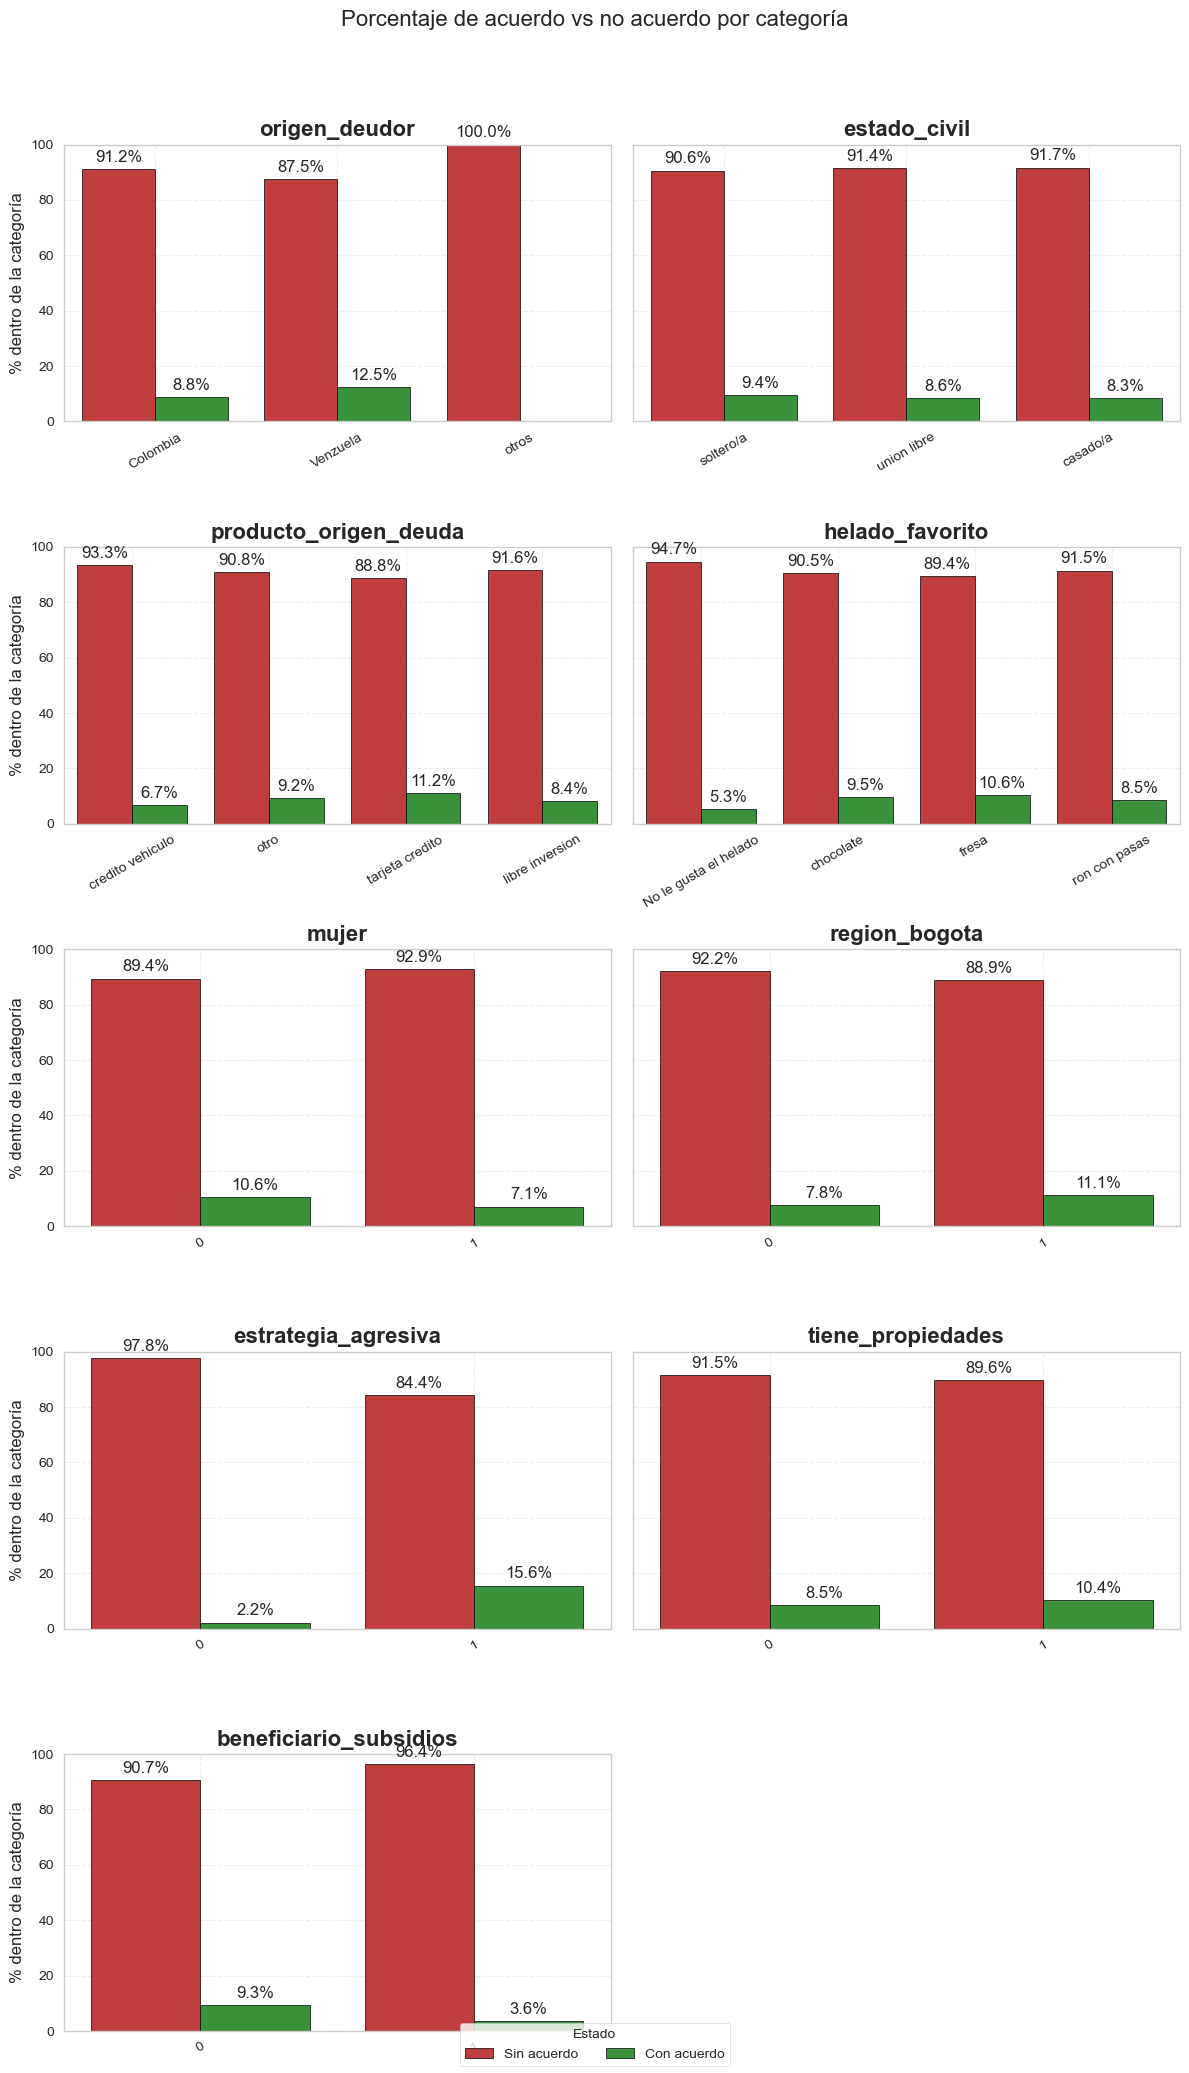

(<Figure size 1200x2000 with 10 Axes>,
 array([<Axes: title={'center': 'origen_deudor'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'estado_civil'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'producto_origen_deuda'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'helado_favorito'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'mujer'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'region_bogota'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'estrategia_agresiva'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'tiene_propiedades'}, ylabel='% dentro de la categoría'>,
        <Axes: title={'center': 'beneficiario_subsidios'}, ylabel='% dentro de la categoría'>,
        <Axes: >], dtype=object))

In [29]:
vars7 = [
    "origen_deudor",
    "estado_civil",
    "producto_origen_deuda",
    "helado_favorito",
    "mujer",
    "region_bogota",
    "estrategia_agresiva",
    "tiene_propiedades",
    "beneficiario_subsidios"
]

plot_risk_panel_two_bars(
    data=data,
    variables=vars7,
    target_col="con_acuerdo",
    top_k=4,
    sort_by="count",
    suptitle="Porcentaje de acuerdo vs no acuerdo por categoría"
)



from sklearn.preprocessing import MinMaxScaler

vars_num = ['gasto_mensual', 'ingresos_mensuales', 'cupo_solicitado', 
             'cupo_aprobado', 'edad', 'mes_aplicacion']

scaler = MinMaxScaler()
data[vars_num] = scaler.fit_transform(data[vars_num])

data[vars_num].head()


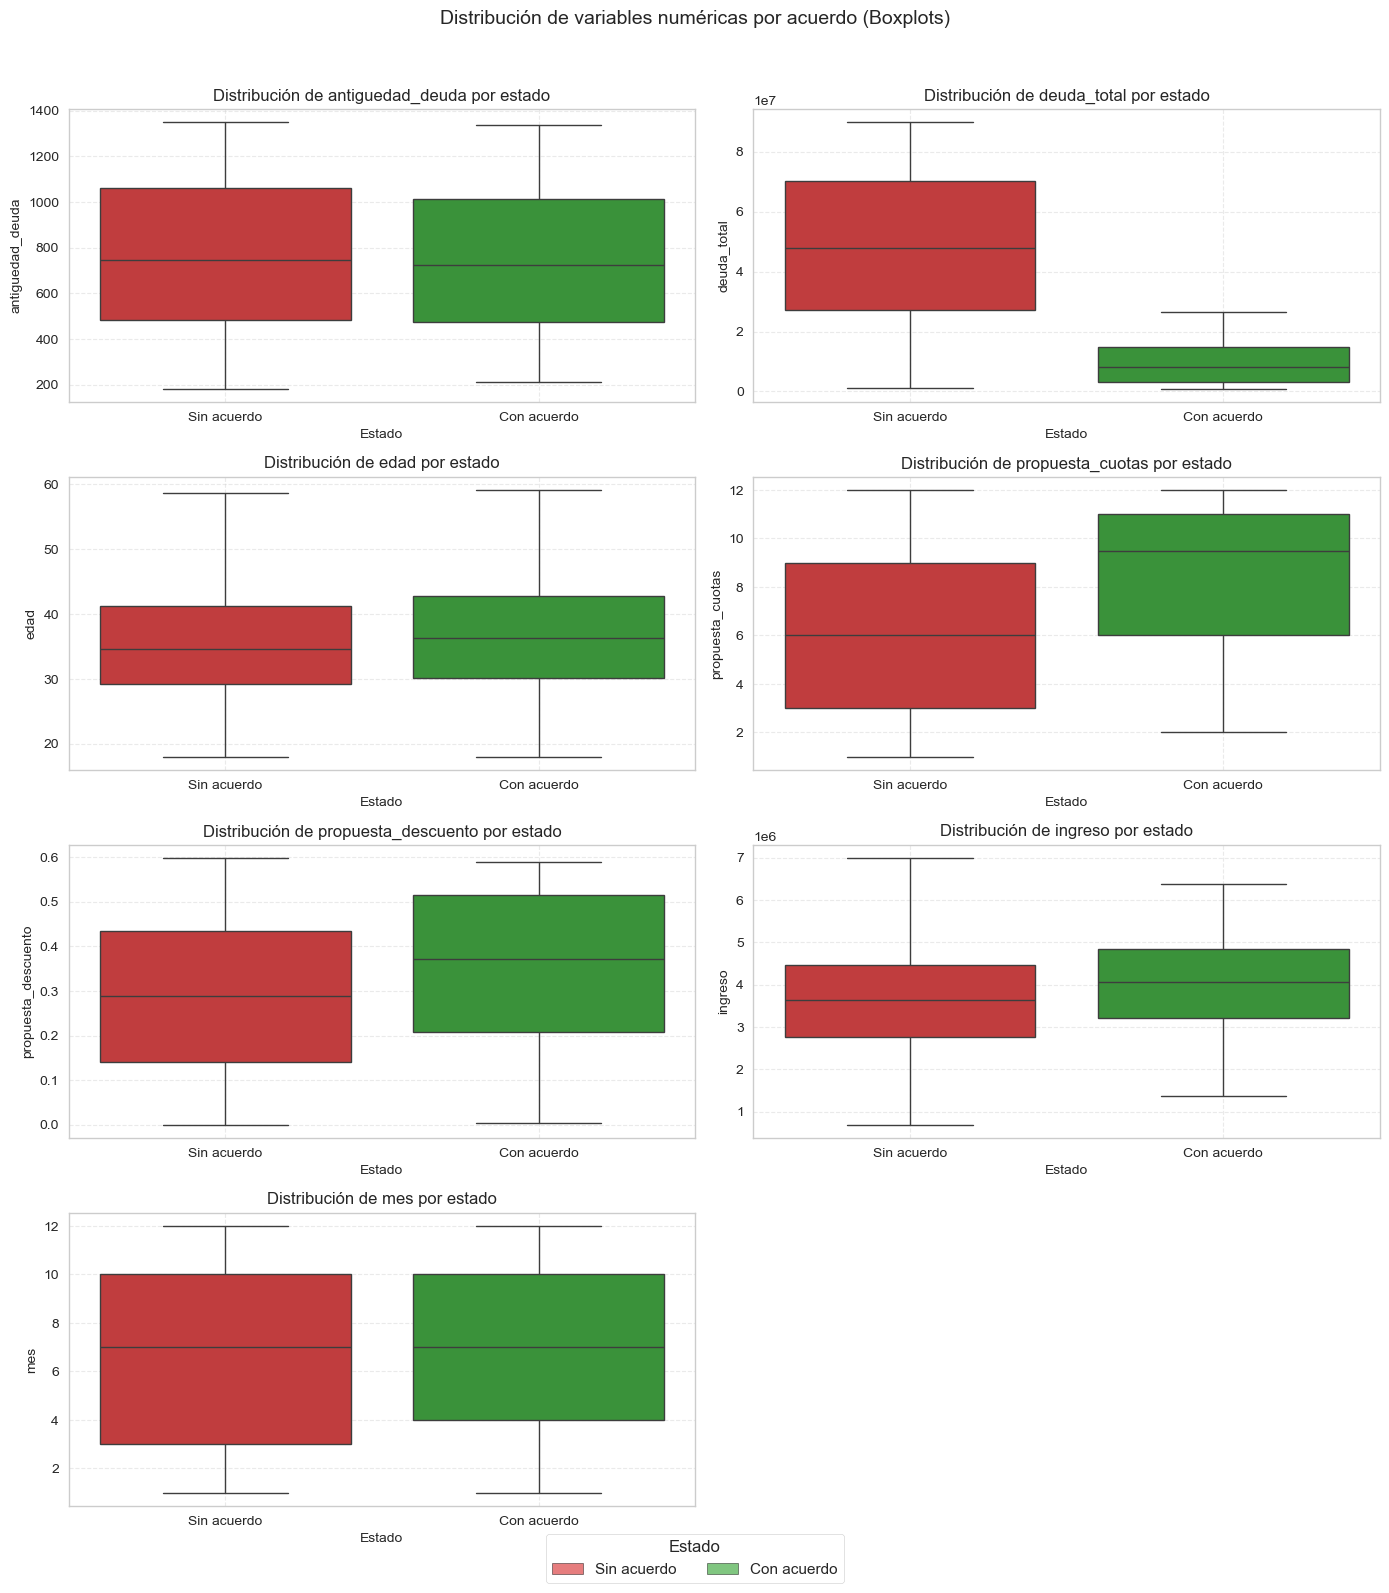

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

def plot_multi_box_legible(df, variables, target='con_acuerdo'):
    data = df.copy()

    # --- Validar target ---
    if target not in data.columns:
        raise ValueError(f"No existe la columna target '{target}'. Columnas: {list(data.columns)}")

    # --- Validar variables ---
    vars_ok = [v for v in variables if v in data.columns]
    missing = [v for v in variables if v not in data.columns]
    if missing:
        print("⚠️ Variables no encontradas (omitidas):", missing)
    if len(vars_ok) == 0:
        raise ValueError("No hay variables válidas para graficar.")

    # --- Normalizar target a 0/1 ---
    if data[target].dtype == object:
        s = data[target].astype(str).str.strip().str.upper()
        mapping = {
            "1": 1, "0": 0,
            "SI": 1, "SÍ": 1, "NO": 0,
            "TRUE": 1, "FALSE": 0,
            "VERDADERO": 1, "FALSO": 0,
            "YES": 1, "Y": 1, "N": 0
        }
        y01 = s.map(mapping)
    elif data[target].dtype == bool:
        y01 = data[target].astype(int)
    else:
        y01 = pd.to_numeric(data[target], errors="coerce")

    # Filtrar solo 0/1
    data = data.loc[y01.isin([0, 1])].copy()
    y01 = y01.loc[y01.isin([0, 1])].astype(int)

    # Etiquetas (ajusta si quieres Cumplido/Incumplido)
    data["_estado"] = y01.map({0: "Sin acuerdo", 1: "Con acuerdo"}).astype("category")

    # Convertir variables a numéricas (por si vienen como texto)
    for v in vars_ok:
        data[v] = pd.to_numeric(data[v], errors="coerce")

    # --- Colores fijos y orden ---
    palette = {"Sin acuerdo": "#d62728", "Con acuerdo": "#2ca02c"}
    order = ["Sin acuerdo", "Con acuerdo"]
    sns.set_style("whitegrid")

    # --- Cuadrícula ---
    n = len(vars_ok)
    ncols = 2
    nrows = (n + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.8 * nrows))
    axes = axes.flatten()

    for i, var in enumerate(vars_ok):
        ax = axes[i]

        sub = data[[var, "_estado"]].dropna()
        if sub.empty:
            ax.set_visible(False)
            continue

        # ✅ NO usar hue si ya pones x=_estado (evita duplicar leyenda)
        sns.boxplot(
            data=sub, x="_estado", y=var,
            order=order, palette=palette,
            showfliers=False,
            ax=ax
        )

        ax.set_title(f"Distribución de {var} por estado", fontsize=12)
        ax.set_xlabel("Estado", fontsize=10)
        ax.set_ylabel(var, fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.4)

    # Ocultar ejes sobrantes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # --- Leyenda global manual ---
    handles = [
        Patch(facecolor=palette["Sin acuerdo"], edgecolor="black", label="Sin acuerdo", alpha=0.6),
        Patch(facecolor=palette["Con acuerdo"], edgecolor="black", label="Con acuerdo", alpha=0.6),
    ]
    fig.legend(
        handles=handles, loc="lower center", ncol=2,
        title="Estado", fontsize=11, title_fontsize=12,
        bbox_to_anchor=(0.5, -0.02)
    )

    plt.suptitle("Distribución de variables numéricas por acuerdo (Boxplots)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


# ✅ Tus variables numéricas correctas
vars_num = [
    "antiguedad_deuda",
    "deuda_total",
    "edad",
    "propuesta_cuotas",
    "propuesta_descuento",
    "ingreso",
    "mes"
]

plot_multi_box_legible(data, vars_num, target="con_acuerdo")


Correlación biserial puntual con la variable objetivo:
estrategia_agresiva       0.2361
propuesta_cuotas          0.2029
ingreso                   0.0992
propuesta_descuento       0.0893
region_bogota             0.0549
edad                      0.0270
tiene_propiedades         0.0245
mes                       0.0238
antiguedad_deuda         -0.0190
beneficiario_subsidios   -0.0559
mujer                    -0.0615
deuda_total              -0.4054
dtype: float64


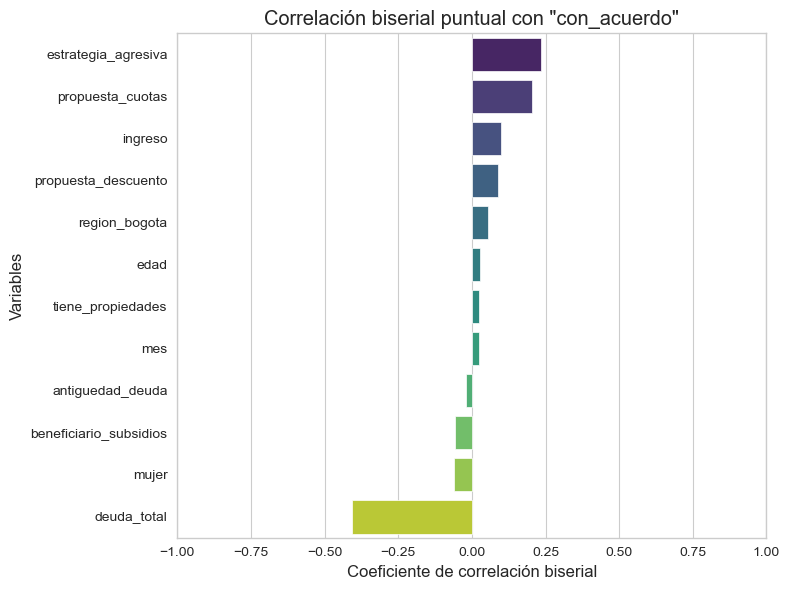

estrategia_agresiva       0.2361
propuesta_cuotas          0.2029
ingreso                   0.0992
propuesta_descuento       0.0893
region_bogota             0.0549
edad                      0.0270
tiene_propiedades         0.0245
mes                       0.0238
antiguedad_deuda         -0.0190
beneficiario_subsidios   -0.0559
mujer                    -0.0615
deuda_total              -0.4054
dtype: float64

In [31]:

from scipy.stats import pointbiserialr

def correlacion_biserial(df, objetivo, figsize=(8, 6)):
    # Seleccionar solo variables numéricas
    num_df = df.select_dtypes(include=['int64', 'float64']).copy()

    # Verificar que el objetivo esté en el DataFrame
    if objetivo not in num_df.columns:
        raise ValueError(f'La variable objetivo "{objetivo}" no está en el DataFrame numérico.')

    # Calcular correlaciones biseriales con la variable objetivo
    corr_dict = {}
    for col in num_df.columns:
        if col != objetivo:
            try:
                r, _ = pointbiserialr(num_df[objetivo], num_df[col])
                corr_dict[col] = r
            except Exception:
                corr_dict[col] = None  # por si alguna variable no se puede correlacionar

    # Convertir a Series y ordenar
    corr_target = pd.Series(corr_dict).dropna().sort_values(ascending=False)

    # Mostrar resultados
    print("Correlación biserial puntual con la variable objetivo:")
    print(corr_target)

    # Graficar
    plt.figure(figsize=figsize)
    sns.barplot(x=corr_target.values, y=corr_target.index, palette='viridis')
    plt.title(f'Correlación biserial puntual con "{objetivo}"')
    plt.xlabel('Coeficiente de correlación biserial')
    plt.ylabel('Variables')
    plt.xlim(-1, 1)
    plt.tight_layout()
    plt.show()

    return corr_target

# Ejemplo de uso
correlacion_biserial(data, 'con_acuerdo')


# Eliminar una variables que presenta alta correlacion

In [32]:
data.drop(columns=['deuda_total'], inplace=True)

In [33]:

#  si quieres solo columnas numéricas de data
correlacion = data.select_dtypes(include='number').corr()

# Pares con correlación > 0.5
pares_alta_corr = [
    (col1, col2, correlacion.loc[col1, col2])
    for i, col1 in enumerate(correlacion.columns)
    for col2 in correlacion.columns[i+1:]
    if abs(correlacion.loc[col1, col2]) > 0.6
]

if pares_alta_corr:
    for col1, col2, corr in pares_alta_corr:
        print(f"{col1} - {col2} → Correlación: {corr:.4f}")
else:
    print("No hay columnas con alta correlación")

region_bogota - ingreso → Correlación: 0.6124


### Conclusiones por variable:

# Positivas (aumentan probabilidad de acuerdo):

estrategia_agresiva (~0.24) → la variable más influyente, estrategia agresiva de cobranza genera más acuerdos
propuesta_cuotas (~0.20) → ofrecer cuotas facilita el acuerdo
ingreso (~0.10) → mayor ingreso, más probabilidad de acuerdo
propuesta_descuento (~0.09) → descuentos ayudan moderadamente

# Negativas (reducen probabilidad de acuerdo):

deuda_total (~-0.40) → la más fuerte, pero confirmado como leakage — eliminar
mujer (~-0.06) → leve diferencia por género
beneficiario_subsidios (~-0.06) → subsidios asociados a menor acuerdo

# Variables con poco impacto (<0.05):

edad, mes, tiene_propiedades, antiguedad_deuda, region_bogota

# Conclusión general: 

sin deuda_total, el modelo dependerá principalmente de la estrategia de cobranza y el tipo de propuesta ofrecida — variables que sí tienen sentido de negocio y no son leakage.

In [34]:
data.head()

,antiguedad_deuda,mujer,edad,region_bogota,propuesta_cuotas,propuesta_descuento,estrategia_agresiva,origen_deudor,estado_civil,tiene_propiedades,producto_origen_deuda,beneficiario_subsidios,helado_favorito,mes,ingreso,con_acuerdo
0,491,0,42.2254,0,5,0.0628,1,Colombia,union libre,0,credito vehiculo,0,ron con pasas,5,4244878.1242,0
1,615,0,27.1348,0,6,0.3268,0,Colombia,soltero/a,0,otro,0,chocolate,7,2860101.8445,0
2,850,0,42.5954,0,6,0.5792,0,Colombia,union libre,0,credito vehiculo,0,otro,2,4547806.2104,0
3,1243,0,27.0014,1,9,0.4848,0,Venzuela,casado/a,0,otro,0,ron con pasas,5,4917511.3706,0
4,416,0,39.5811,0,9,0.2590,0,Colombia,soltero/a,1,tarjeta credito,0,otro,12,4045892.0007,0


In [35]:
# ── 1. Preparar y ─────────────────────────────────────────────────
mapping = {
    "1": 1, "0": 0, "SI": 1, "SÍ": 1, "NO": 0,
    "TRUE": 1, "FALSE": 0, "VERDADERO": 1, "FALSO": 0,
    "YES": 1, "Y": 1, "N": 0
}

y = data['con_acuerdo'].copy()
if y.dtype == object:
    y = y.astype(str).str.strip().str.upper().map(mapping)
elif y.dtype == bool:
    y = y.astype(int)
else:
    y = pd.to_numeric(y, errors='coerce')

In [36]:
# ── 2. Preparar X ─────────────────────────────────────────────────
features = [f for f in (vars_num + vars7) if f in data.columns]
X = data[features].copy()

mask_valid = y.isin([0, 1]) & X.notnull().all(axis=1)
X = X.loc[mask_valid].reset_index(drop=True)
y = y.loc[mask_valid].astype(int).reset_index(drop=True)

In [37]:
# ── 3. Splits ─────────────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train, Val, Test shapes:", X_train.shape, X_val.shape, X_test.shape)


Train, Val, Test shapes: (600, 15) (200, 15) (200, 15)


In [38]:
# ── 4. Preprocesador ──────────────────────────────────────────────
vars_cat  = [f for f in vars7    if f in X.columns]
vars_num2 = [f for f in vars_num if f in X.columns]

preprocessor = ColumnTransformer([
    ('ohe',    OneHotEncoder(handle_unknown='ignore'), vars_cat),
    ('scaler', StandardScaler(),                       vars_num2)
])

In [39]:
# ── 5. Optuna ─────────────────────────────────────────────────────
def objective(trial):
    C       = trial.suggest_float('C', 0.001, 100, log=True)
    solver  = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])
    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    if solver == 'lbfgs' and penalty == 'l1':
        raise optuna.exceptions.TrialPruned()

    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', LogisticRegression(
                    C=C, solver=solver, penalty=penalty,
                    class_weight='balanced', max_iter=1000
        ))
    ])
    pipe.fit(X_train, y_train)
    return roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("Mejores parámetros:", study.best_params)
print(f"Mejor AUC-ROC:     {study.best_value:.4f}")


Best trial: 15. Best value: 0.86821: 100%|██████████| 50/50 [00:02<00:00, 17.63it/s]

Mejores parámetros: {'C': 0.18806474777688775, 'solver': 'saga', 'penalty': 'l1'}
Mejor AUC-ROC:     0.8682


In [40]:
# ── 6. Reentrenar con mejores parámetros ──────────────────────────
best = study.best_params
pipe_lr_opt = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(
                C=best['C'], solver=best['solver'], penalty=best['penalty'],
                class_weight='balanced', max_iter=1000
    ))
])
pipe_lr_opt.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
# ── 7. Predicciones ───────────────────────────────────────────────
y_pred = pipe_lr_opt.predict(X_val)
y_prob = pipe_lr_opt.predict_proba(X_val)[:, 1]

In [42]:
# ── 8. Métricas ───────────────────────────────────────────────────
print("\n=== Logistic Regression Optimizada ===")
print(classification_report(y_val, y_pred))


=== Logistic Regression Optimizada ===
              precision    recall  f1-score   support

           0       0.96      0.80      0.88       183
           1       0.23      0.65      0.34        17

    accuracy                           0.79       200
   macro avg       0.60      0.73      0.61       200
weighted avg       0.90      0.79      0.83       200



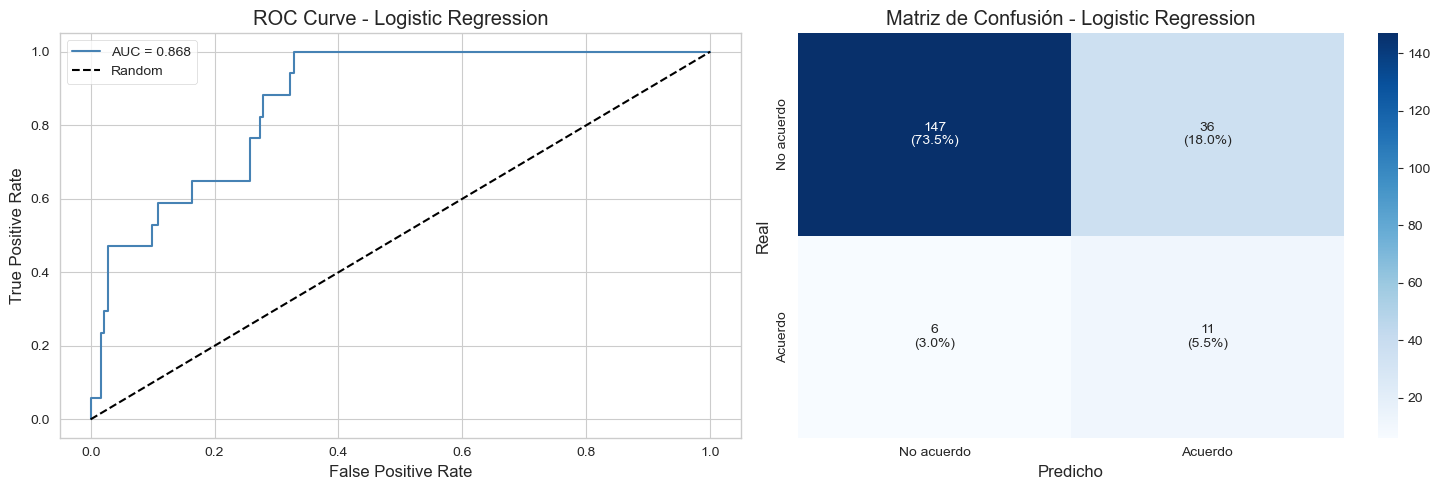

AUC-ROC: 0.8682


In [43]:
# ── 9. Gráficos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Logistic Regression')
axes[0].legend()

# Matriz de Confusión
cm     = confusion_matrix(y_val, y_pred)
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[1],
            xticklabels=['No acuerdo', 'Acuerdo'],
            yticklabels=['No acuerdo', 'Acuerdo'])
axes[1].set_title('Matriz de Confusión - Logistic Regression')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc:.4f}")

In [44]:
# ── 3. Splits ─────────────────────────────────────────────────────
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print("Train, Val, Test shapes:", X_train.shape, X_val.shape, X_test.shape)

Train, Val, Test shapes: (600, 15) (200, 15) (200, 15)


In [45]:
# ── 4. Preprocesador ──────────────────────────────────────────────
vars_cat  = [f for f in vars7   if f in X.columns]
vars_num2 = [f for f in vars_num if f in X.columns]

preprocessor = ColumnTransformer([
    ('ohe',    OneHotEncoder(handle_unknown='ignore'), vars_cat),
    ('scaler', StandardScaler(),                       vars_num2)
])

In [46]:
# ── 5. Logistic Regression ────────────────────────────────────────
pipe_lr = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(class_weight='balanced', max_iter=100))
])
pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [47]:
# Métricas
print("\n=== Logistic Regression ===")
print(classification_report(y_val, pipe_lr.predict(X_val)))


=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.95      0.80      0.87       183
           1       0.21      0.59      0.31        17

    accuracy                           0.78       200
   macro avg       0.58      0.69      0.59       200
weighted avg       0.89      0.78      0.82       200



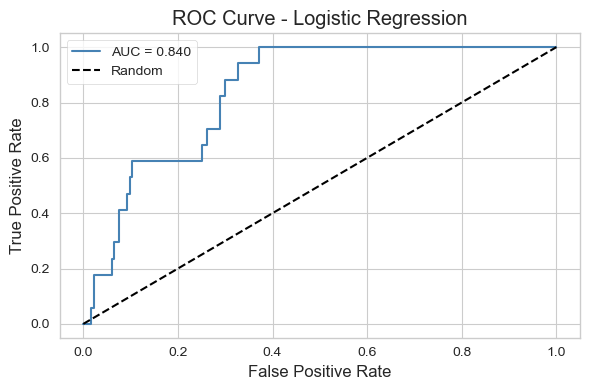

AUC-ROC: 0.8396


In [48]:
# ROC-AUC
y_prob_lr = pipe_lr.predict_proba(X_val)[:, 1]
fpr, tpr, _ = roc_curve(y_val, y_prob_lr)
auc = roc_auc_score(y_val, y_prob_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC-ROC: {auc:.4f}")

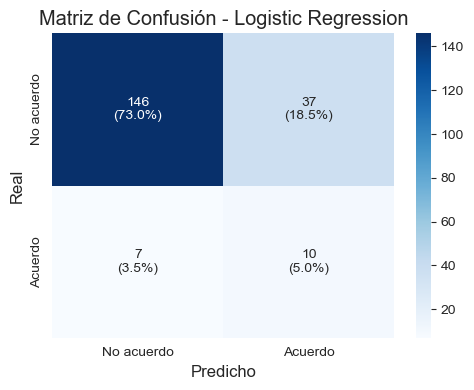

In [49]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_lr = pipe_lr.predict(X_val)
cm = confusion_matrix(y_val, y_pred_lr)
cm_pct = cm / cm.sum() * 100

labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues',
            xticklabels=['No acuerdo', 'Acuerdo'],
            yticklabels=['No acuerdo', 'Acuerdo'])
plt.title('Matriz de Confusión - Logistic Regression')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

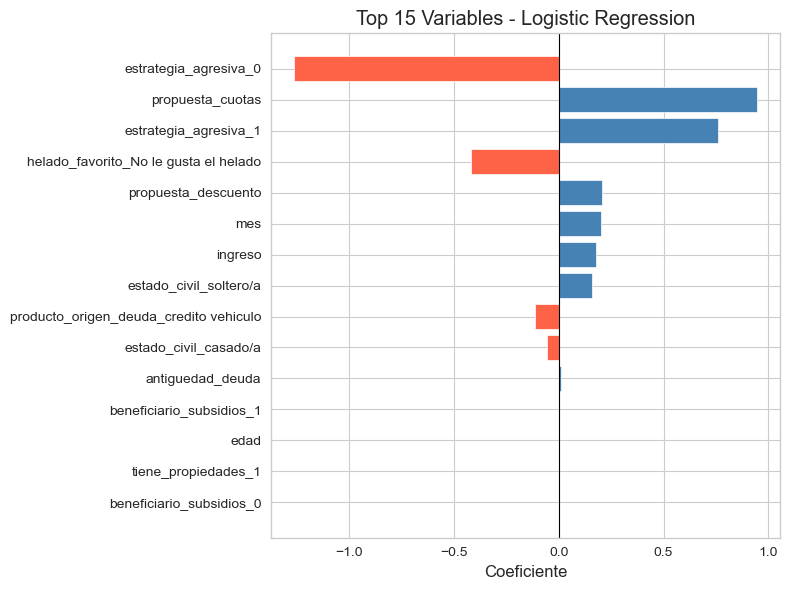

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Coeficientes del modelo
ohe_cols  = pipe_lr_opt.named_steps['prep'].transformers_[0][1].get_feature_names_out(vars_cat)
num_cols  = pipe_lr_opt.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_cols  = list(ohe_cols) + list(num_cols)

coefs = pipe_lr_opt.named_steps['model'].coef_[0]

df_imp = pd.DataFrame({'variable': all_cols, 'coeficiente': coefs})
df_imp['abs'] = df_imp['coeficiente'].abs()
df_imp = df_imp.sort_values('abs', ascending=True).tail(15)

colores = ['tomato' if c < 0 else 'steelblue' for c in df_imp['coeficiente']]

plt.figure(figsize=(8, 6))
plt.barh(df_imp['variable'], df_imp['coeficiente'], color=colores)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Coeficiente')
plt.title('Top 15 Variables - Logistic Regression')
plt.tight_layout()
plt.show()

In [51]:

# ── 2. Optuna XGBoost ─────────────────────────────────────────────
def objective_xgb(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma':             trial.suggest_float('gamma', 0, 5),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0, 5),
    }

    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', XGBClassifier(
                    **params,
                    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                    eval_metric='auc',
                    random_state=42,
                    verbosity=0
        ))
    ])
    pipe.fit(X_train, y_train)
    return roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print("Mejores parámetros:", study_xgb.best_params)
print(f"Mejor AUC-ROC:     {study_xgb.best_value:.4f}")

Best trial: 48. Best value: 0.916426: 100%|██████████| 50/50 [00:15<00:00,  3.24it/s]

Mejores parámetros: {'n_estimators': 72, 'max_depth': 10, 'learning_rate': 0.011753342976680714, 'subsample': 0.6659634454360535, 'colsample_bytree': 0.5465043923507651, 'gamma': 2.5089892855179246, 'reg_alpha': 3.0822399549423274, 'reg_lambda': 0.279898831873568}
Mejor AUC-ROC:     0.9164


In [52]:
# ── 2. Reentrenar con mejores parámetros ──────────────────────────
best_xgb = study_xgb.best_params
pipe_xgb = Pipeline([
    ('prep',  preprocessor),
    ('model', XGBClassifier(
                **best_xgb,
                scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                eval_metric='auc',
                random_state=42,
                verbosity=0
    ))
])
pipe_xgb.fit(X_train, y_train)

,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [53]:
# ── 3. Predicciones ───────────────────────────────────────────────
y_pred = pipe_xgb.predict(X_val)
y_prob = pipe_xgb.predict_proba(X_val)[:, 1]

In [54]:
# ── 4. Métricas ───────────────────────────────────────────────────
print("\n=== XGBoost Optimizado ===")
print(classification_report(y_val, y_pred))


=== XGBoost Optimizado ===
              precision    recall  f1-score   support

           0       0.97      0.89      0.93       183
           1       0.38      0.71      0.49        17

    accuracy                           0.88       200
   macro avg       0.67      0.80      0.71       200
weighted avg       0.92      0.88      0.89       200



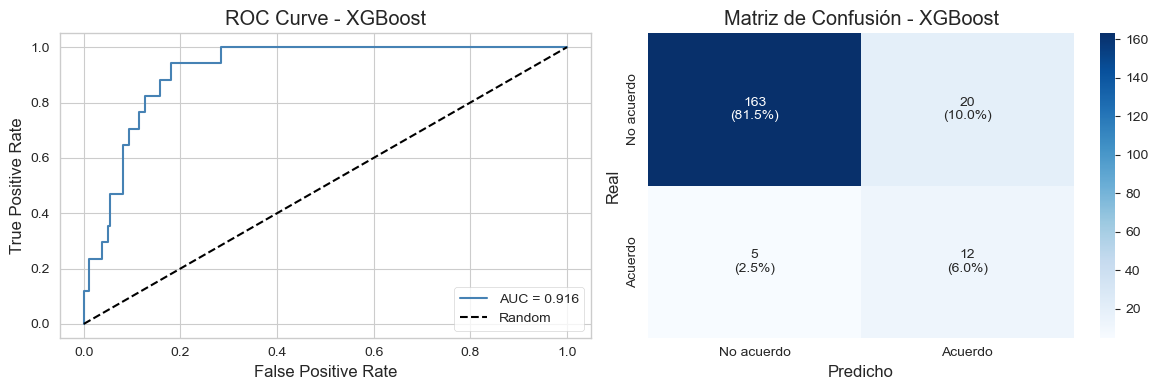

AUC-ROC: 0.9164


In [55]:
# ── 5. Gráficos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - XGBoost')
axes[0].legend()

# Matriz de Confusión
cm     = confusion_matrix(y_val, y_pred)
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[1],
            xticklabels=['No acuerdo', 'Acuerdo'],
            yticklabels=['No acuerdo', 'Acuerdo'])
axes[1].set_title('Matriz de Confusión - XGBoost')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc:.4f}")

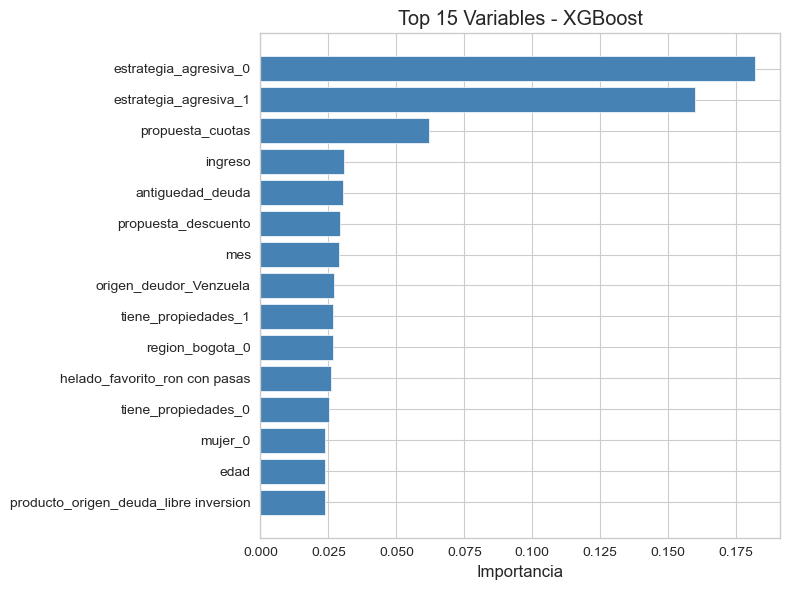

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# Importancia del modelo
ohe_cols  = pipe_xgb.named_steps['prep'].transformers_[0][1].get_feature_names_out(vars_cat)
num_cols  = pipe_xgb.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_cols  = list(ohe_cols) + list(num_cols)

importancias = pipe_xgb.named_steps['model'].feature_importances_

df_imp = pd.DataFrame({'variable': all_cols, 'importancia': importancias})
df_imp = df_imp.sort_values('importancia', ascending=True).tail(15)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['variable'], df_imp['importancia'], color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 15 Variables - XGBoost')
plt.tight_layout()
plt.show()

In [57]:
# ── 1. Optuna Random Forest ───────────────────────────────────────
def objective_rf(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
    }

    pipe = Pipeline([
        ('prep',  preprocessor),
        ('model', RandomForestClassifier(
                    **params,
                    class_weight='balanced',
                    random_state=42,
                    n_jobs=-1
        ))
    ])
    pipe.fit(X_train, y_train)
    return roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])

study_rf = optuna.create_study(direction='maximize')
study_rf.optimize(objective_rf, n_trials=50, show_progress_bar=True)

print("Mejores parámetros:", study_rf.best_params)
print(f"Mejor AUC-ROC:     {study_rf.best_value:.4f}")

Best trial: 22. Best value: 0.90614: 100%|██████████| 50/50 [00:50<00:00,  1.02s/it] 

Mejores parámetros: {'n_estimators': 496, 'max_depth': 5, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 'sqrt'}
Mejor AUC-ROC:     0.9061


In [58]:
# ── 2. Reentrenar con mejores parámetros ──────────────────────────
best_rf = study_rf.best_params
pipe_rf = Pipeline([
    ('prep',  preprocessor),
    ('model', RandomForestClassifier(
                **best_rf,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
    ))
])
pipe_rf.fit(X_train, y_train)


,steps,"[('prep', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('ohe', ...), ('scaler', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [59]:
# ── 3. Predicciones ───────────────────────────────────────────────
y_pred = pipe_rf.predict(X_val)
y_prob = pipe_rf.predict_proba(X_val)[:, 1]

In [60]:
# ── 4. Métricas ───────────────────────────────────────────────────
print("\n=== Random Forest Optimizado ===")
print(classification_report(y_val, y_pred))


=== Random Forest Optimizado ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94       183
           1       0.40      0.59      0.48        17

    accuracy                           0.89       200
   macro avg       0.68      0.75      0.71       200
weighted avg       0.91      0.89      0.90       200



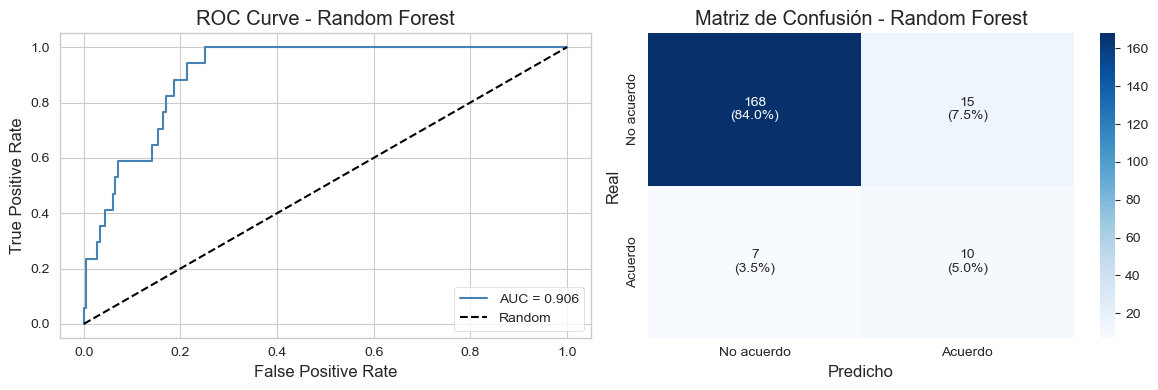

AUC-ROC: 0.9061


In [61]:
# ── 5. Gráficos ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_prob)
auc = roc_auc_score(y_val, y_prob)
axes[0].plot(fpr, tpr, label=f'AUC = {auc:.3f}', color='steelblue')
axes[0].plot([0,1], [0,1], 'k--', label='Random')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].legend()

# Matriz de Confusión
cm     = confusion_matrix(y_val, y_pred)
cm_pct = cm / cm.sum() * 100
labels = [[f"{cm[i,j]}\n({cm_pct[i,j]:.1f}%)" for j in range(2)] for i in range(2)]
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[1],
            xticklabels=['No acuerdo', 'Acuerdo'],
            yticklabels=['No acuerdo', 'Acuerdo'])
axes[1].set_title('Matriz de Confusión - Random Forest')
axes[1].set_ylabel('Real')
axes[1].set_xlabel('Predicho')

plt.tight_layout()
plt.show()
print(f"AUC-ROC: {auc:.4f}")

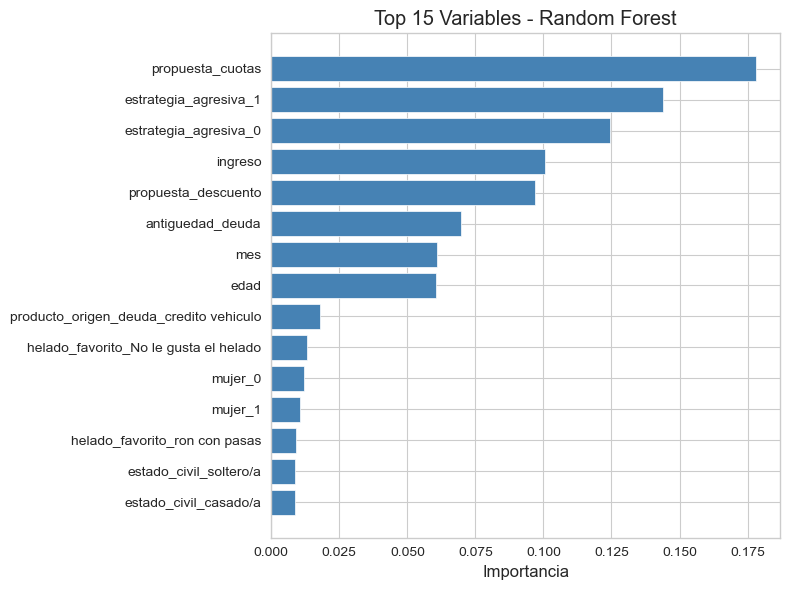

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Importancia del modelo
ohe_cols  = pipe_rf.named_steps['prep'].transformers_[0][1].get_feature_names_out(vars_cat)
num_cols  = pipe_rf.named_steps['prep'].transformers_[1][1].get_feature_names_out()
all_cols  = list(ohe_cols) + list(num_cols)

importancias = pipe_rf.named_steps['model'].feature_importances_

df_imp = pd.DataFrame({'variable': all_cols, 'importancia': importancias})
df_imp = df_imp.sort_values('importancia', ascending=True).tail(15)

plt.figure(figsize=(8, 6))
plt.barh(df_imp['variable'], df_imp['importancia'], color='steelblue')
plt.xlabel('Importancia')
plt.title('Top 15 Variables - Random Forest')
plt.tight_layout()
plt.show()